In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from qiskit_ibm_runtime.fake_provider import FakeAuckland, FakeManilaV2
#from qiskit_ibm_runtime import SamplerV2 as Sampler

In [3]:
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit.circuit.library import RealAmplitudes
from qiskit.quantum_info import Operator, SparsePauliOp

In [19]:
x0 = 0
y0 = 0.2

step_size = 0.1

xn = 0.4

In [20]:
X = np.arange(x0, xn + step_size, step_size)


In [21]:
#z = np.log(np.abs(-y))
h = np.log(np.abs(step_size))

In [ ]:
#Real Hardware
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()

backend = service.least_busy(operational=True, simulator=False)


In [7]:
#Fake Backend
backend = FakeManilaV2()

In [8]:
estimator = Estimator(backend)

In [9]:
qc = QuantumCircuit(1)

qc.h(0)

In [ ]:
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_psi = pm.run(qc)

In [26]:
y_pred = [y0]
y = y0

for i in X[1:]:

    Y = -y
    z = np.log(np.abs(Y))

    h_m = np.array([[h, 0],
                    [0, z]])

    opm = Operator(h_m)
    h_m = SparsePauliOp.from_operator(opm)

    isa_observables1 = h_m.apply_layout(isa_psi.layout)
    job1 = estimator.run([(isa_psi, isa_observables1)], precision=0.001 )

    job_result1 = job1.result()[0] # It will block until the job finishes.
    expv1 = job_result1.data.evs
    m = np.exp(2*expv1) * np.sign(Y)
    #print(i, "m:", np.round(m, 2), ",", "Y:", np.round(Y, 2) )
    
    h_s = np.array([[y, 0],
                    [0, m]])

    ops = Operator(h_s)
    h_s = SparsePauliOp.from_operator(ops)

    isa_observables2 = h_s.apply_layout(isa_psi.layout)
    job2 = estimator.run([(isa_psi, isa_observables2)], precision=0.001)

    job_result2 = job2.result()[0] # It will block until the job finishes.
    expv2 = job_result2.data.evs
    ans = 2*expv2

    y = ans
    #print("y", np.round(y, 2))
    y_pred.append(y)
    


In [30]:
# initial condition
y_true = [y0]
y = y0

# Euler method
for i in X[1:]:
    Y = -y

    y = y + step_size * (Y)   # dy/dx = -y
    y_true.append(y)

# print results
# for x, y in zip(x_vals, y_vals):
#     print(f"x = {x}, y = {y}")

In [31]:
print(len(X), len(y_pred), len(y_true))

5 5 5


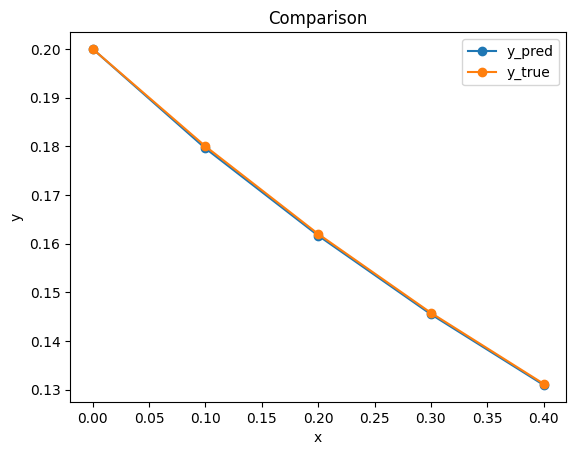

In [32]:
import matplotlib.pyplot as plt

plt.plot(X, y_pred, 'o-', label="y_pred")  # dots + line
plt.plot(X, y_true, 'o-', label="y_true")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Comparison")
plt.legend()

plt.show()

In [33]:
mse = sum((a - b)**2 for a, b in zip(y_pred, y_true)) / len(y_pred)
print(mse)

8.518163439402711e-08


In [34]:
import pandas as pd

df = pd.DataFrame({
    "x": X,
    "y_pred": y_pred,
    "y": y_true
})

print(df)

     x    y_pred        y
0  0.0  0.200000  0.20000
1  0.1  0.179579  0.18000
2  0.2  0.161670  0.16200
3  0.3  0.145508  0.14580
4  0.4  0.130987  0.13122


In [37]:
import pickle

data = {
    "y_pred_eu" : y_pred
}

with open("data.pkl", "wb") as f:
    pickle.dump(data, f)